In [140]:
"""We have two tables- SQLite_file (with 'UserName',	'Revenue','Salary',	and 'AverageClicks' columns), and the other (with 'FullName' and 'RegistrationDate' columns) which is called CRM_file. These datasets relate to one typical month, and  are presented as two Excel files in the same directory as this Jupyter Notebook). At the end of each month, the sales department needs to match the usage data from SQLite_file with the CRM_file for each user for further analysis. Note that the user names in both sources may not be consistent; so, exact matching/comparison may not work for 100% cases. The solution should include multiple matching strategies that can be applied to maximize the matching rate. The number of rows in the tables are the same, 44, and only the name representations are different.

1)	Propose a Python solution that will solve the matching problem above – reads the data from two Excel files, matches both inputs by client names, and saves the result to the database.
2) Choose a polynomial model to fit the variations of 'Revenue' with regard to the 'Salary', and 'AverageClicks' columns
3) plot the heat map of the correlation between each pair of numerical columns in SQLite_file table.
"""

"We have two tables- SQLite_file (with 'UserName',\t'Revenue','Salary',\tand 'AverageClicks' columns), and the other (with 'FullName' and 'RegistrationDate' columns) which is called CRM_file. These datasets relate to one typical month, and  are presented as two Excel files in the same directory as this Jupyter Notebook). At the end of each month, the sales department needs to match the usage data from SQLite_file with the CRM_file for each user for further analysis. Note that the user names in both sources may not be consistent; so, exact matching/comparison may not work for 100% cases. The solution should include multiple matching strategies that can be applied to maximize the matching rate. The number of rows in the tables are the same, 44, and only the name representations are different.\n\n1)\tPropose a Python solution that will solve the matching problem above – reads the data from two Excel files, matches both inputs by client names, and saves the result to the database.\n2) Choo

In [141]:
"""
In this implementation file, I use fuzzywuzzy library to analyze matching process in two csv table, representing extracted files from databases.
"""

'\nIn this implementation file, I use fuzzywuzzy library to analyze matching process in two csv table, representing extracted files from databases.\n'

In [142]:
## Installation of fuzzywuzzy and python-Levenshtein 
"""
!pip install fuzzywuzzy
!pip install python-Levenshtein
!pip install pandas
!pip install openpyxl
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
"""

'\n!pip install fuzzywuzzy\n!pip install python-Levenshtein\n!pip install pandas\n!pip install openpyxl\n!pip install scikit-learn\n!pip install matplotlib\n!pip install seaborn\n'

In [143]:
# Importing the required libraries
from fuzzywuzzy import fuzz 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
# Reading two Excel files representing the source files extracted from the databases:
# SQLITE_file contains four columns with 'UserName', 'Revenue per Month, 'Salary per Month', and 'Number of Clicks per Day', and CRM_file has two columns- 'Full Name', 'Registration Date'. Both the files have 44 rows of data.
# I read the tables as dataframe:
SQLITE_TABLE = pd.read_excel('SQLITE_file.xlsx')
CRM_TABLE = pd.read_excel('CRM_file.xlsx')

In [145]:
# I show the name columns of the two table for your consideration:
pd.concat([SQLITE_TABLE.UserName, CRM_TABLE.FullName], axis = 1)

,UserName,FullName
0,"Adams, E.",Samantha Grace Wright
1,"Anderson, Sophi, Miss",Sophia Lee
2,"Roustaee, Sr. A",Matthew Taylor
3,"A. Martinez, MSc",Jacob Wilson
4,"D. Biden, PhD.",Olivia Murphy
5,Dr. Jessi Miller,Alexander Anderson
6,PhD. Lauren Martinez,Saeedeh Taban
7,"Mohseni, Jr. Eli",Lauren Martinez
8,"Emily Moore, Jr.",Emily Moore
9,"Ethan Simpson, Miss",Ethan Simpson


In [146]:
# Combining all the words from the UserName column into one single string, where each word is separated by a space.
allwords = ' '. join(SQLITE_TABLE['UserName'])

# creating a list of 'allwords' elements 
list_of_allwords = allwords.split(' ')

# calculation of the words frequencies
word_count = pd.Series(list_of_allwords).value_counts()

# changing the pandas series to a dataframe
df_word_count = word_count.to_frame()

# adding 'Titles' header to the dataframe
df_word_count.index.name = 'Titles'

# changing the Titles index to a column
df_word_count.reset_index(inplace = True)
df_word_count.head()

,Titles,count
0,Mr.,8
1,Jr.,5
2,Sr.,4
3,Ms.,4
4,Miss,4


In [147]:
# Those words happening more than 3 times in the UserName column are considered as redundant and are omitted
stopwords = df_word_count[df_word_count['count']>2]['Titles'].tolist()
stopwords

['Mr.', 'Jr.', 'Sr.', 'Ms.', 'Miss', 'PhD.', 'Prof.', 'MSc', 'Dr.']

In [148]:
# creating a new column, named 'CorrectedName', where the undesirable words are omitted, and adding
# it to the SQLITE_TABLE:
SQLITE_TABLE['CorrectedName'] = SQLITE_TABLE.apply(lambda row: 
                                        ' '.join([word for word in row.iloc[0].split()
                                                  if word not in stopwords]), axis=1)
SQLITE_TABLE[['UserName', 'CorrectedName', 'Revenue', 'Salary', 'AverageClicks']]


,UserName,CorrectedName,Revenue,Salary,AverageClicks
0,"Adams, E.","Adams, E.",122.764706,2888.936661,69.332968
1,"Anderson, Sophi, Miss","Anderson, Sophi,",132.558824,2117.530129,47.888931
2,"Roustaee, Sr. A","Roustaee, A",54.705882,794.558390,50.101070
3,"A. Martinez, MSc","A. Martinez,",67.470588,1343.173252,59.174328
4,"D. Biden, PhD.","D. Biden,",62.647059,1096.393212,46.305192
5,Dr. Jessi Miller,Jessi Miller,61.617647,1455.960612,22.129889
6,PhD. Lauren Martinez,Lauren Martinez,140.352941,2577.017758,85.675038
7,"Mohseni, Jr. Eli","Mohseni, Eli",120.352941,2692.462843,157.352451
8,"Emily Moore, Jr.","Emily Moore,",77.588235,1593.595386,109.759323
9,"Ethan Simpson, Miss","Ethan Simpson,",93.205882,1695.889639,108.501486


In [149]:
# To probe the matching states of the rows in two tables, I take advantage of the merge() method to
# cross join them. In this condition, every row of SQLITE_TABLE is compared with every row of the 
# CRM_TABLE. To examine the similarity states of each pair of names (FullName from CRM_TABLE and 'CorrectedName' 
# from SQLITE_TABLE), I use Fuzzy string matching from fuzzywuzzy library, considering different states of
# matching between two given string sets based on specific algorithms.

# For cross joining the tables, I add the same zero column, 'key', to the tables.
SQLITE_TABLE['key'] = 0
CRM_TABLE['key'] = 0


# Building the cross joint table and dropping the 'key' column:
joint_table = pd.merge(SQLITE_TABLE, CRM_TABLE, on='key').drop('key', axis=1)
joint_table

# Rearrangement of the columns of the joint_table for more convinience
joint_table = joint_table[['CorrectedName', 'FullName', 'UserName', 'Revenue', 'Salary', 'AverageClicks','RegistrationDate']]
joint_table.head(15)

,CorrectedName,FullName,UserName,Revenue,Salary,AverageClicks,RegistrationDate
0,"Adams, E.",Samantha Grace Wright,"Adams, E.",122.764706,2888.936661,69.332968,2019-09-25
1,"Adams, E.",Sophia Lee,"Adams, E.",122.764706,2888.936661,69.332968,2019-02-20
2,"Adams, E.",Matthew Taylor,"Adams, E.",122.764706,2888.936661,69.332968,2022-03-26
3,"Adams, E.",Jacob Wilson,"Adams, E.",122.764706,2888.936661,69.332968,2020-05-26
4,"Adams, E.",Olivia Murphy,"Adams, E.",122.764706,2888.936661,69.332968,2022-04-15
5,"Adams, E.",Alexander Anderson,"Adams, E.",122.764706,2888.936661,69.332968,2022-07-17
6,"Adams, E.",Saeedeh Taban,"Adams, E.",122.764706,2888.936661,69.332968,2021-10-27
7,"Adams, E.",Lauren Martinez,"Adams, E.",122.764706,2888.936661,69.332968,2021-02-09
8,"Adams, E.",Emily Moore,"Adams, E.",122.764706,2888.936661,69.332968,2020-07-26
9,"Adams, E.",Ethan Simpson,"Adams, E.",122.764706,2888.936661,69.332968,2018-07-28


In [150]:
joint_table['S_R'] = joint_table.apply(lambda row: fuzz.ratio(row.iloc[0], row.iloc[1]), axis=1)
joint_table['P_R'] = joint_table.apply(lambda row: fuzz.partial_ratio(row.iloc[0], row.iloc[1]), axis=1)
joint_table['SORT_R'] = joint_table.apply(lambda row: fuzz.token_sort_ratio(row.iloc[0], row.iloc[1]), axis=1)
joint_table['SET_R'] = joint_table.apply(lambda row: fuzz.token_set_ratio(row.iloc[0], row.iloc[1]), axis=1)

# I also calculate the sum of all fuzzy malgorithms and plug the result in a new column, 'fuzzySUM', and append
# it to the joint_table
joint_table['fuzzySUM'] = joint_table[['S_R', 'P_R', 'SORT_R', 'SET_R']].sum(axis=1)
joint_table[['CorrectedName', 'FullName', 'S_R', 'P_R', 'SORT_R', 'SET_R', 'fuzzySUM']]

,CorrectedName,FullName,S_R,P_R,SORT_R,SET_R,fuzzySUM
0,"Adams, E.",Samantha Grace Wright,20,33,29,29,111
1,"Adams, E.",Sophia Lee,21,22,12,12,67
2,"Adams, E.",Matthew Taylor,17,22,19,19,77
3,"Adams, E.",Jacob Wilson,19,22,21,21,83
4,"Adams, E.",Olivia Murphy,18,22,20,20,80
...,...,...,...,...,...,...,...
1931,"W., Samantha",Emily Adams,26,27,29,29,111
1932,"W., Samantha",Jacob Martinez,23,26,33,33,115
1933,"W., Samantha",Michael Swift,24,29,43,43,139
1934,"W., Samantha",Ava Perez,10,11,32,32,85


In [151]:
# The cross joint table above considers the comparison between all the names
# included in the 'FullName' and 'CorrectedName' columns. I group the joint_table by 'CorrectedName'
# and find the index of maximum value of fuzzySUM within each group;
# The returned table is called 'table_of_max_index':
max_index = joint_table.groupby('CorrectedName')['fuzzySUM'].idxmax().reset_index()
max_index.columns = ['CorrectedName', 'Index_of_maximum_fuzzySUM']
max_index

,CorrectedName,Index_of_maximum_fuzzySUM
0,"A. Martinez,",164
1,"Adams, E.",39
2,Alex Anderson,841
3,"Anderson, Sophi,",75
4,Andrew A.,901
5,Chloe Scott,936
6,"D. Biden,",193
7,D. Wilson,990
8,Elizabeth Harris,1041
9,"Emily Moore,",360


In [152]:
# Using the max_index, I find the rows corresponding to the maximum value of fuzzySUM for each 'correctedName',
# indicating the best match. Then, I remove the 'CorrectedName' column, and the result is returned
# as the 'best_match_table'
best_match_table = joint_table.iloc[max_index.Index_of_maximum_fuzzySUM, :].reset_index().drop(['index', 'CorrectedName'], axis = 1)
best_match_table

,FullName,UserName,Revenue,Salary,AverageClicks,RegistrationDate,S_R,P_R,SORT_R,SET_R,fuzzySUM
0,Ava Martinez,"A. Martinez, MSc",67.470588,1343.173252,59.174328,2020-07-07,83,83,91,91,348
1,Emily Adams,"Adams, E.",122.764706,2888.936661,69.332968,2019-02-25,50,71,78,83,282
2,Alexander Anderson,Mr. Alex Anderson,33.235294,734.453075,38.026660,2022-07-17,84,77,84,84,329
3,Sophia Anderson,"Anderson, Sophi, Miss",132.558824,2117.530129,47.888931,2018-03-18,52,53,97,97,299
4,Andrew Allen,Mr. Andrew A.,78.970588,1213.645228,56.355121,2019-03-01,76,89,80,86,331
5,Chloe Scott,Mr. Chloe Scott,128.823529,2265.853638,142.129848,2020-11-10,100,100,100,100,400
6,David Biden,"D. Biden, PhD.",62.647059,1096.393212,46.305192,2021-11-04,70,71,78,83,302
7,David Wilson,Mr. D. Wilson,52.029412,804.312692,44.785906,2021-04-04,76,78,80,86,320
8,Elizabeth Harris,Mr. Elizabeth Harris,99.735294,2124.829163,165.713029,2020-04-02,100,100,100,100,400
9,Emily Moore,"Emily Moore, Jr.",77.588235,1593.595386,109.759323,2020-07-26,96,100,100,100,396


In [153]:
# table_of_ratio_index
table_of_ratio_index = joint_table.groupby('FullName').agg({'S_R': 'idxmax', 'P_R': 'idxmax',
                                'SORT_R': 'idxmax', 'SET_R': 'idxmax'})

# To see the added 'reliability' column to the table_of_ratio_index and its number of unique
# value for each name in the 'FullName' column, we have:

table_of_ratio_index['reliability'] = table_of_ratio_index[['S_R', 'P_R', 'SORT_R', 'SET_R']].nunique(axis=1)
table_of_ratio_index

,S_R,P_R,SORT_R,SET_R,reliability
FullName,,,,,
Alexander Anderson,841,841,841,841,1
Andrew Allen,901,901,901,901,1
Anna Thompson,1775,1775,1775,1775,1
Arman Roustaee,124,124,124,124,1
Ashley Nelson,864,864,1436,1436,2
Ava Martinez,164,164,164,164,1
Ava Perez,1274,1274,1538,1538,2
Chloe Scott,936,936,936,936,1
Chloe Thompson,1793,1793,1837,1837,2


In [154]:
Suspected_entries = table_of_ratio_index[table_of_ratio_index.reliability > 2]
Suspected_entries

,S_R,P_R,SORT_R,SET_R,reliability
FullName,,,,,
Lauren Miller,302,1182,830,830,3
Sophia Anderson,867,1659,75,75,3


In [155]:
DOUBLED_CHECKED = best_match_table.set_index('FullName').loc[Suspected_entries.index, :].reset_index()
DOUBLED_CHECKED

,FullName,UserName,Revenue,Salary,AverageClicks,RegistrationDate,S_R,P_R,SORT_R,SET_R,fuzzySUM
0,Lauren Miller,"Miller, Mr. Lauren",139.264706,2760.500252,173.475694,2019-07-06,44,46,100,100,290
1,Sophia Anderson,"Anderson, Sophi, Miss",132.558824,2117.530129,47.888931,2018-03-18,52,53,97,97,299


In [156]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [157]:
degrees = [1, 2, 3, 4, 5] # different degrees of polynomials for fitting the data
cv = 4  # the number of folds
model = LinearRegression() # setting the model
S = pd.Series(index = range(len(degrees)))  # empty pandas series

for degree in degrees:
    poly = PolynomialFeatures(degree = degree) # the polynomial objects
    X_poly = poly.fit_transform(SQLITE_TABLE[['Salary', 'AverageClicks']])
    S.iloc[degree-1]= cross_val_score(model, X_poly, SQLITE_TABLE['Revenue'], cv=4).mean()
    
best_polynomial_degree = S.idxmax()+1
print(f'R_squared results for different degree of polynomial model:\n {S}\n\n')
print(f' The best_polynomial_degree = {best_polynomial_degree}')


R_squared results for different degree of polynomial model:
 0     0.834925
1     0.842193
2     0.810722
3    -0.655104
4   -10.499404
dtype: float64


 The best_polynomial_degree = 2


In [158]:
correlation = SQLITE_TABLE.drop('key', axis = 1).select_dtypes(include = 'number').corr()

<Axes: >

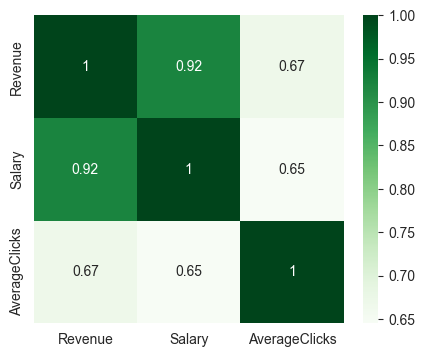

In [159]:
# Plotting the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(correlation, annot=True, cmap='Greens', linewidths=0)
